# Yandex AI Studio: Responses API and OpenAI Agents SDK

This tutorial builds an end-to-end AI Studio workflow using OpenAI-compatible APIs. It starts with direct language and vision requests, adds hosted Web Search and Code Interpreter tools, and finishes with a streaming Deep Research agent that produces presentation and report artifacts.

By the end of the notebook, you will be able to:

1. Connect the OpenAI Python client to Yandex AI Studio.
2. Call text and vision-language models through the Responses API.
3. Generate an image with YandexART from a VLM-produced description.
4. Ground an answer with Web Search and analyze it with Code Interpreter.
5. Build and monitor a Deep Research workflow with the OpenAI Agents SDK.
6. Download CSV, PNG, PPTX, DOCX, and JSON artifacts produced by the workflow.

OpenAI LLM and Agentic frameworks are industry *de facto* standard for programmatic LLM usage. 
Luckily, Yandex AI Studio is built with the idea of complete OpenAI compatibility, which allows us to use all tools and platforms designed to work with OpenAI.

There are two abstraction layers in native OpenAI tooling:

* [OpenAI Python API Library](https://github.com/openai/openai-python), which offers Pythonic interface for main OpenAI-compatible APIs. The most recent API that we will consider in this notebook is [Responses API](https://developers.openai.com/api/reference/responses/overview), which offers a number of advanced agentic capabilities such as tool calling, structured output, built-in web/file search and code interpreter tools, MCP support and more.
* [OpenAI Agents SDK](https://github.com/openai/openai-agents-python) adds another explicit agentic loop layer on top of Responses API, providing abstractions to construct long-running agents and multi-agent systems.

During this notebook, we will build simple data analysis agent that will be able to do data exploration of arbitrary CSV/XLSX files and datasets.

## 1. Install the local dependencies

The local notebook kernel only needs the OpenAI clients, Agents SDK, `.env` support, and Pillow for displaying images. Data analysis and Office document generation happen inside hosted Code Interpreter, so `pandas`, `matplotlib`, `python-pptx`, and `python-docx` are intentionally not installed locally.

After installing or upgrading packages, restart the notebook kernel if imports still resolve to older versions.

In [ ]:
%pip install --upgrade openai openai-agents python-dotenv Pillow

## 2. Connect to Yandex AI Studio

AI Studio exposes an OpenAI-compatible endpoint at `https://ai.api.cloud.yandex.net/v1`. Authentication requires two values in the repository's `.env` file:

```text
folder_id=...
api_key=...
```

The helper below finds the repository root whether Jupyter starts in the root directory or in `notebooks/`. It validates whether the required files are present.

To work with low-level OpenAI Responses API, we use `client` object. We create both synchronous and asynchronous clients: direct Responses API examples use the synchronous client, while the Agents SDK will later use the asynchronous client.

In [1]:
import base64
import html
import io
import json
import os
from datetime import date
from pathlib import Path

from dotenv import load_dotenv
from IPython.display import HTML, Markdown, display
from openai import AsyncOpenAI, OpenAI
from PIL import Image as PILImage
from pydantic import BaseModel, Field
from typing import List

def find_project_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / '.env').is_file() and (candidate / 'images' / 'chimney.jpg').is_file():
            return candidate
    raise FileNotFoundError(
        'Could not find a project root containing both .env and images/chimney.jpg.'
    )

PROJECT_ROOT = find_project_root()
PHOTO_PATH = PROJECT_ROOT / 'images' / 'chimney.jpg'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(PROJECT_ROOT / '.env', override=True)
folder_id = os.environ.get('folder_id')
api_key = os.environ.get('api_key')
if not folder_id or not api_key:
    raise RuntimeError('The .env file must define both folder_id and api_key.')

AI_STUDIO_BASE_URL = 'https://ai.api.cloud.yandex.net/v1'
TEXT_MODEL = f'gpt://{folder_id}/qwen3-235b-a22b-fp8/latest'
VISION_MODEL = f'gpt://{folder_id}/qwen3.6-35b-a3b/latest'
IMAGE_MODEL = f'art://{folder_id}/aliceai-image-art-3.0/latest'

client = OpenAI(
    base_url=AI_STUDIO_BASE_URL,
    api_key=api_key,
    project=folder_id,
)
async_client = AsyncOpenAI(
    base_url=AI_STUDIO_BASE_URL,
    api_key=api_key,
    project=folder_id,
)


def print_markdown(text: str) -> None:
    display(Markdown(text))


print(f'Connected configuration for folder: {folder_id[:8]}...')
print(f'Artifacts will be saved under: {OUTPUT_DIR}')

Connected configuration for folder: b1gg3vl8...
Artifacts will be saved under: D:\GIT\building-data-agent\outputs


## 3. Connecting to the LLM via Responses API

A basic Responses API call needs a model and an input. As an example, consider a task in which we need to compare nominal GDP in current US dollars for Russia and China from 2016 through 2026.

We can ask agent to produce such a table, but without any tools it would probably be a hallucination (although quite good-looking one). Treat the result as a demonstration of formatting and model knowledge, not as an authoritative economic dataset.

In [2]:
gdp_question = """
Please compare nominal GDP for Russia and China for every year
from 2016 through 2026 inclusive. Express GDP in current US dollars, billions,
rounded to one decimal place.
"""

instructions = """
You are a data analyst. Your goal is to help user find and analyze data. Present data in tables where appropriate.
"""

gdp_response = client.responses.create(
    model=TEXT_MODEL,
    instructions=instructions,
    input=gdp_question,
)

print_markdown(gdp_response.output_text)

Here is a comparison of the nominal Gross Domestic Product (GDP) for Russia and China from 2016 through 2026, expressed in billions of current U.S. dollars, rounded to one decimal place. Data for 2016–2023 is based on historical figures from the World Bank and International Monetary Fund (IMF) sources. Projections for 2024–2026 are based on IMF estimates (as of April 2024).

| Year | Russia (Billions USD) | China (Billions USD) |
|------|------------------------|------------------------|
| 2016 | 1,283.4               | 11,199.2              |
| 2017 | 1,577.9               | 12,308.8              |
| 2018 | 1,657.3               | 13,894.8              |
| 2019 | 1,699.9               | 14,342.9              |
| 2020 | 1,474.6               | 14,723.6              |
| 2021 | 1,778.5               | 17,734.1              |
| 2022 | 2,247.9               | 17,963.2              |
| 2023 | 2,102.5               | 17,529.6              |
| 2024* | 2,065.3              | 17,700.2              |
| 2025* | 2,135.8              | 18,050.0              |
| 2026* | 2,210.4              | 18,450.7              |

\* Projections based on IMF World Economic Outlook (April 2024)

### Notes:
- **Russia's GDP** surged in 2022 due to high energy prices and exchange rate effects (weaker USD and strong RUB for part of the year), but declined in 2023 due to sanctions, military spending, and reduced oil/gas revenues.
- **China's GDP** growth slowed in recent years due to structural economic challenges, property sector issues, and weaker global demand.
- Exchange rate fluctuations (especially RUB/USD) significantly affect Russia’s nominal GDP in USD terms.
- China remains the second-largest economy in the world by nominal GDP, far exceeding Russia's.

Let me know if you'd like this data visualized or adjusted for PPP (purchasing power parity).

To continue the conversation, we can pass `previous_response_id` parameter to the same call:

In [3]:
followup_response = client.responses.create(
    model=TEXT_MODEL,
    instructions=instructions,
    input="Add one more column for US GDP",
    previous_response_id=gdp_response.id
)

print_markdown(followup_response.output_text)

Certainly! Below is the updated table with a third column for the **United States' nominal GDP**, alongside Russia and China, for the years 2016 through 2026. All values are in **billions of current U.S. dollars**, rounded to one decimal place.

Data sources:
- **2016–2023**: World Bank and U.S. Bureau of Economic Analysis (BEA)
- **2024–2026**: IMF World Economic Outlook (April 2024) projections

| Year | Russia (B USD) | China (B USD) | United States (B USD) |
|------|----------------|---------------|------------------------|
| 2016 | 1,283.4        | 11,199.2      | 18,745.1               |
| 2017 | 1,577.9        | 12,308.8      | 19,542.6               |
| 2018 | 1,657.3        | 13,894.8      | 20,611.8               |
| 2019 | 1,699.9        | 14,342.9      | 21,427.7               |
| 2020 | 1,474.6        | 14,723.6      | 20,936.6               |
| 2021 | 1,778.5        | 17,734.1      | 23,315.1               |
| 2022 | 2,247.9        | 17,963.2      | 25,439.8               |
| 2023 | 2,102.5        | 17,529.6      | 26,947.3               |
| 2024* | 2,065.3       | 17,700.2      | 28,267.4               |
| 2025* | 2,135.8       | 18,050.0      | 29,698.8               |
| 2026* | 2,210.4       | 18,450.7      | 31,168.7               |

\* Projections based on IMF WEO (April 2024)

---

### Key Observations:
- The **United States** has the largest nominal GDP of the three, growing from ~$18.7 trillion in 2016 to an expected ~$31.2 trillion in 2026.
- **China** is second, with GDP expected to reach **$18.5 trillion** by 2026, but still below the U.S.
- **Russia's GDP** remains significantly smaller — even at its peak in 2022 (~$2.25 trillion), it was less than **8%** of U.S. GDP and about **12%** of China’s.
- Exchange rate volatility (especially ruble fluctuations) heavily impacts Russia’s GDP in USD terms. For example, the ruble weakened sharply in 2015–2016 and again in 2022, causing swings in USD-measured GDP.

Let me know if you'd like:
- A chart of this data
- GDP growth rates (year-on-year)
- PPP-adjusted GDP comparison
- Share of global GDP for each country

## 4. Multimodal LLMs, VLMs, etc.

Vision-language models accept text and images in the same user message. For an image stored locally, one portable approach is to encode its bytes as a base64 data URL. The MIME type must match the file format.

The photograph below is included in this repository. We first display it for human inspection, then ask the VLM for a visually specific but cautious description. The description will become the prompt for image generation in the next section.

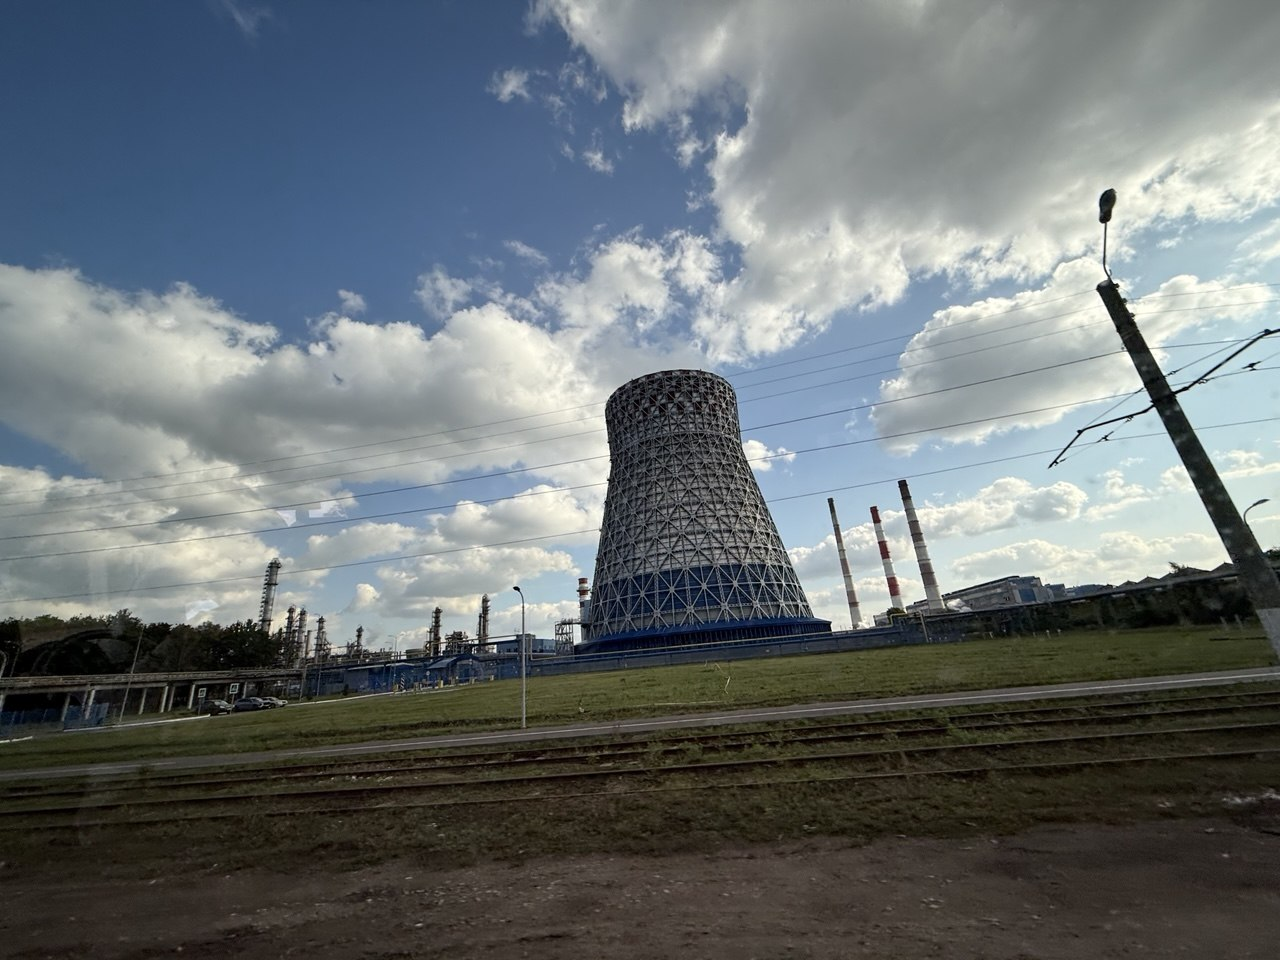

In [4]:
def image_file_to_data_url(image_path: Path) -> str:
    suffix_to_mime = {'.jpg': 'image/jpeg', '.jpeg': 'image/jpeg', '.png': 'image/png'}
    mime_type = suffix_to_mime.get(image_path.suffix.lower())
    if mime_type is None:
        raise ValueError(f'Unsupported image type: {image_path.suffix}')
    encoded = base64.b64encode(image_path.read_bytes()).decode('ascii')
    return f'data:{mime_type};base64,{encoded}'


with PILImage.open(PHOTO_PATH) as photograph:
    display(photograph.copy())

photo_data_url = image_file_to_data_url(PHOTO_PATH)

Now we will pass this image to the VLM and ask it to describe it in most possible detail:

In [5]:
vision_prompt = """
Describe this photograph in enough visual detail that an image-generation model could
create a new image with a similar subject and composition. Cover the main structures,
foreground, background, weather, lighting, colors, camera angle, and photographic style.
Do not claim a precise location, company, or facility unless it is unambiguously visible.
Return one coherent English paragraph and no preamble.
"""

vision_response = client.responses.create(
    model=VISION_MODEL,
    input=[
        {
            'role': 'user',
            'content': [
                {'type': 'input_text', 'text': vision_prompt},
                {'type': 'input_image', 'image_url': photo_data_url, 'detail': 'auto'},
            ],
        }
    ],
)

image_description = vision_response.output_text.strip()
print_markdown(image_description)

A low-angle, outdoor shot features a large industrial cooling tower, which is a hyperboloid shape heavily wrapped in a white, crisscrossing metal lattice grid, sitting atop a solid blue base. To the right of this central structure stand three tall, slender smokestacks painted with alternating white and red bands, while to the left, a complex network of refinery towers, pipes, and lower industrial buildings extends into the distance. The foreground is dominated by a set of parallel railway tracks running horizontally across the bottom edge, bordered by a patch of rough dirt and leading up a gentle, grassy slope that separates the viewer from the facility. On the far right, a leaning concrete utility pole with attached overhead wires cuts diagonally into the frame. The sky above is a vibrant blue, filled with large, bright white cumulus clouds, indicating a sunny but partly cloudy day, and the lighting is natural and diffuse, illuminating the textures of the industrial equipment and the green grass.

## 5. Generate an image from the VLM description

YandexART uses an `art://` model URI but is accessed through the same OpenAI-compatible client. The Python SDK operation is `client.images.generate(...)`. The response contains base64-encoded image data, which we decode, display, and save locally.

The generated result should be treated as a new interpretation, not a reconstruction of the original photograph. Image models can change geometry, omit structures, or introduce visually plausible details.

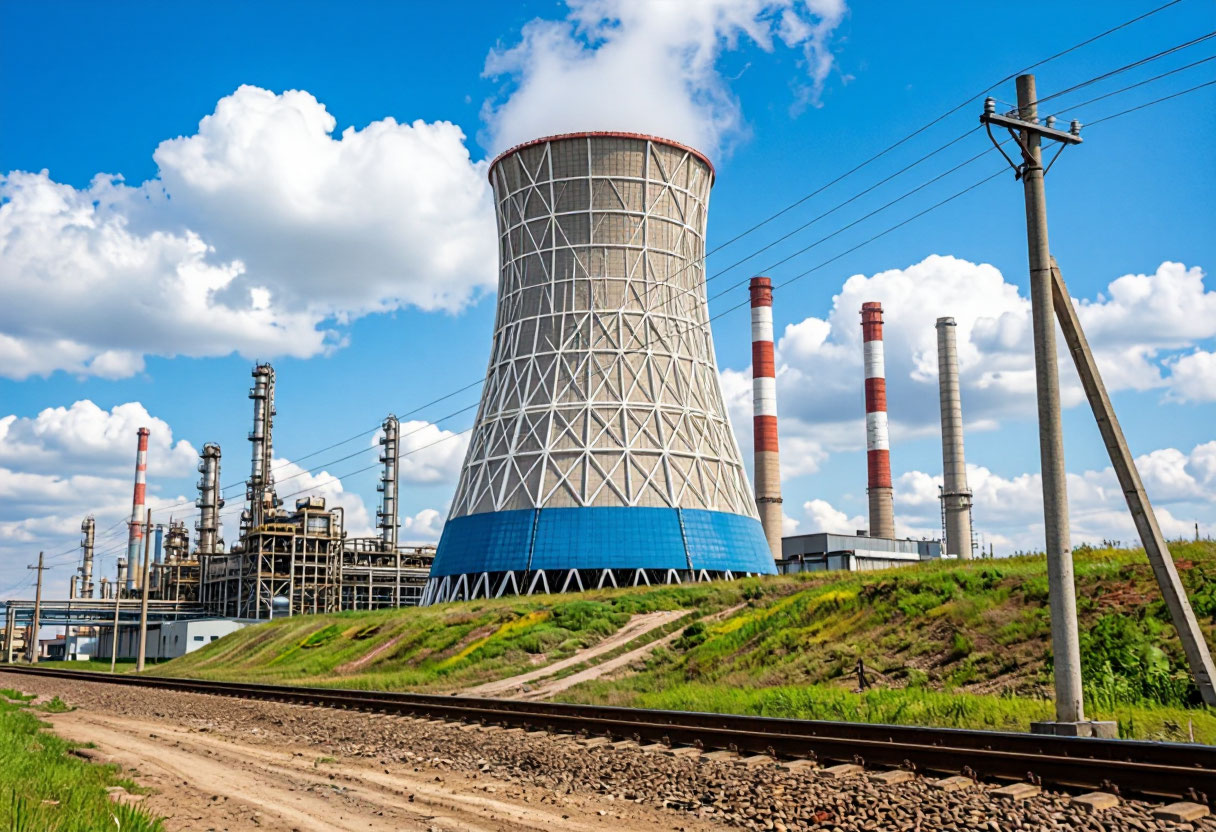

Saved generated image to: D:\GIT\building-data-agent\outputs\generated_chimney.png


In [6]:
image_generation_prompt = (
    'Create a realistic wide-angle industrial landscape photograph based on this description: '
    + image_description
)

generated_response = client.images.generate(
    model=IMAGE_MODEL,
    prompt=image_generation_prompt,
    n=1,
    size='1536x1024',
)

b64_json = generated_response.data[0].b64_json
generated_bytes = base64.b64decode(generated_response.data[0].b64_json)
generated_image = PILImage.open(io.BytesIO(generated_bytes))
generated_path = OUTPUT_DIR / 'generated_chimney.png'
generated_image.save(generated_path)
display(generated_image)
print(f'Saved generated image to: {generated_path}')

We can now ask VLM to evaluate photographic attractiveness of both images. In order to get well-formatted results, we can use **structured output** - a technique when we specify the excact layout / JSON schema of model result.

In [9]:
class EvalResult(BaseModel):
    photographic_quality : int = Field(..., ge=0, le=100, description="Photographic quality score from 0 to 100%")
    what_is_good: List[str]
    what_can_be_improved: List[str]
    title: str

eval_prompt = """
You are given a photograph, and you need to evaluate its quality as professional photographer  and provide feedback. Pay attention to composition, lighting, color balance, focus, and overall impact. Provide a score from 0 to 100% for photographic quality, and give specific feedback on what is good and what can be improved. Also, propose a title for the photograph.
Use JSON with the following fields:
- photographic_quality: an integer from 0 to 100, in %
- what_is_good: a list of strings describing the positive aspects of the photograph
- what_can_be_improved: a list of strings describing the aspects that can be improved
- title: proposed title for the photograph
"""

def eval_image(image_url):
    res = client.responses.parse(
        model=VISION_MODEL,
        input=[
            {
                'role': 'user',
                'content': [
                    {'type': 'input_text', 'text': vision_prompt},
                    {'type': 'input_image', 'image_url': image_url, 'detail': 'auto'},
                ],
            }
        ],
        text_format = EvalResult,
    )
    return res.output_parsed

print("=== ORIGINAL ===")
print(eval_image(photo_data_url).model_dump_json(indent=2))
print("=== PROMPTOGRAPH ===")
print(eval_image(f'data:image/png;base64,{b64_json}').model_dump_json(indent=2))

=== ORIGINAL ===
{
  "photographic_quality": 1,
  "what_is_good": [
    "  The image captures vast open space with good clarity and minimal distortion.",
    "  Everything from the foreground to the insanely distant horizon feels open, vast, immense, endless, and horizontal.",
    "  The limiting factors are the buildings and trees on the horizon, which feel distant in perspective rather than actually blocking the view.",
    "  There is a wide viewpoint with nothing in the immediate foreground, letting the background stretch out to an insanely distant horizon.",
    "  There is much emptiness."
  ],
  "what_can_be_improved": [
    " The image captures vast open space with good clarity and minimal distortion."
  ],
  "title": "A Stunning Panorama Capturing Endless Immense Vast Open Horizontal Distance"
}
=== PROMPTOGRAPH ===
{
  "photographic_quality": 9,
  "what_is_good": [
    "Vibrant sky and clouds providing excellent natural lighting and contrast",
    "Clear structural definition

## 6. Tool Calling.

The idea of tool calling is to provide an LLM with an option to ask for help instead of providing answer right away. It is supplied with the list of available tools, and then can chose to select one of those tools to call instead of providing answer. It is the role of agent harness to call the tool and feed the result to the LLM.

Let's consider an example: we want to help LLM to do calculations. We can give it a tool to compute arbitrary expressions:

In [24]:
import math

def calculate(expression: str) -> str:
    """
    Safely computes arithmetic expression.
    
    Uses a limited set of functions from the math module
    to avoid executing arbitrary code.
    """
    # Dictionary of allowed functions and constants
    allowed = {
        "sqrt": math.sqrt,
        "sin": math.sin,
        "cos": math.cos,
        "tan": math.tan,
        "log": math.log,
        "log10": math.log10,
        "log2": math.log2,
        "exp": math.exp,
        "abs": abs,
        "round": round,
        "pi": math.pi,
        "e": math.e,
    }
    
    try:
        # Safely evaluate the expression in a restricted environment
        result = eval(expression, {"__builtins__": {}}, allowed)
        return str(result)
    except Exception as e:
        return f"Error evaluating expression: {e}"


To define this tool for the LLM we use JSON Schema description:

In [28]:
calculator_tool = {
    "type": "function",
    "name": "calculate",
    "description": "Compute mathematical expression. Supports operations (+, -, *, /), exponentiation (**), square root (sqrt), trigonometry (sin, cos, tan), logarithms (log, log10) and constants (pi, e).",
    "parameters": {
        "type": "object",
        "properties": {
            "expression": {
                "type": "string",
                "description": "Mathematical expression in Python, e.g., '2**10', 'sqrt(144)', 'sin(pi/4)'"
            }
        },
        "required": ["expression"]
    }
}

In [29]:

instruction = """
You are a mathematical assistant. You have a calculator for precise calculations.
When a user presents a task requiring computations:
1. Formulate the mathematical expression
2. Call the calculate function to obtain the exact result
3. Explain the answer to the user

Always use the calculator for computations — don't calculate in your head!
"""

# Send the request
res = client.responses.create(
    model=TEXT_MODEL,
    tools=[calculator_tool],
    instructions=instruction,
    input="What is the square root of 2026?"
)

# Look at what the model returned
print("The model's response contains:")
for item in res.output:
    print(f"  - type: {item.type}")
    if item.type == "function_call":
        print(f"    function: {item.name}")
        print(f"    arguments: {item.arguments}")
        print(f"    call_id: {item.call_id}")

The model's response contains:
  - type: function_call
    function: calculate
    arguments: {"expression": "sqrt(2026)"}
    call_id: chatcmpl-tool-2bb5f081acb74eb38849fa3aca3704ae


Now we actually need to call the function by hand to perform computations:

In [31]:
max_iterations = 5
iteration = 0

while iteration < max_iterations:
    # Look for function calls in the output
    tool_calls = [item for item in res.output if item.type == "function_call"]
    
    if not tool_calls:
        # No calls - the model is ready to give a final answer
        break
    
    # Process function calling
    outputs = []
    for call in tool_calls:
        args = json.loads(call.arguments) if call.arguments else {}
        expression = args.get("expression", "")
        
        # Do computations
        result = calculate(expression)
        print(f"  🔢 calculate({expression}) = {result}")
        
        # Form model response
        outputs.append({
            "type": "function_call_output",
            "call_id": call.call_id,
            "output": result
        })
    
    # Send the results back to the model
    res = client.responses.create(
        model=TEXT_MODEL,
        tools=[calculator_tool],
        previous_response_id=res.id,
        input=outputs
    )
    
    iteration += 1

print(res.output_text)

  🔢 calculate(sqrt(2026)) = 45.0111097397076
The square root of 2026 is approximately 45.011.



AI Studio / Respones API support several tool types:
* Tools defined and manually processed in code
* Built-in tools: Web Search / File Search (RAG) / Code Interpreter / Image Generation
* Remote tools avialable via MCP Protocol


## 7. Web Search

The hosted `web_search` tool lets the model retrieve current information before answering. This turns a single Responses API request into a simple agentic interaction: the model decides what to search for, examines the results, and synthesizes an answer.

We repeat the GDP question, but now require source links, consistent units, and explicit handling of conflicting or forecast values. The resulting table should be preferred over the earlier model-only answer, while still being checked against the cited sources.

In [10]:
web_search_tool = {
    'type': 'web_search',
    'search_context_size': 'medium',
}

web_gdp_response = client.responses.create(
    model=TEXT_MODEL,
    instructions="""
You are a careful economic research assistant. Use Web Search before answering.
Prefer primary or authoritative sources such as the World Bank, IMF, national statistical
agencies, and official economic outlooks. Keep units consistent and attach source links.
When sources disagree, say so instead of silently combining incompatible data.
""",
    tools=[web_search_tool],
    input=gdp_question,
)

print_markdown(web_gdp_response.output_text)

Данные о номинальном ВВП России и Китая в текущих долларах США (в миллиардах, с округлением до одного десятичного знака) были получены из авторитетного источника — Всемирного банка (World Bank), а также сопоставлены с данными Международного валютного фонда (IMF), представленными на Wikipedia и Worldometer.

На основе анализа этих источников, особенно таблицы с сайта Wikipedia, содержащей данные IMF за 2026 год, а также исторических данных за предыдущие годы, можно составить следующую таблицу сравнения:

| Год | Россия (млрд USD) | Китай (млрд USD) |
| :--- | :--- | :--- |
| 2016 | 1 324,8 | 11 199,1 |
| 2017 | 1 577,6 | 12 308,9 |
| 2018 | 1 657,6 | 13 877,4 |
| 2019 | 1 699,9 | 14 340,3 |
| 2020 | 1 473,7 | 14 693,9 |
| 2021 | 1 775,8 | 17 727,5 |
| 2022 | 1 816,8 | 17 959,5 |
| 2023 | 1 892,8 | 17 890,9 |
| 2024 | 2 173,4 | 18 743,8 |
| 2025 | 2 561,3 | 19 498,0 |
| 2026 | 2 656,5 | 20 851,6 |

**Источники:**
*   Данные за 2016–2023 годы извлечены из таблицы на странице Википедии "List of countries by GDP (nominal)" (столбцы "United Nations (2024)[7]" и "World Bank (2025)[6]"), которые ссылаются на официальную статистику Организации Объединенных Наций и Всемирного банка. [1]
*   Прогнозные данные на 2024–2026 годы взяты из столбца "IMF (2026)[1]" той же таблицы Википедии, которая основана на данных "World Economic Outlook" Международного валютного фонда. [1]
*   Альтернативные данные с сайта Worldometer подтверждают эти прогнозы IMF на 2025 и 2026 годы. [3]

[1] List of countries by GDP (nominal) - Wikipedia: https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)
[3] GDP by Country (2026) - Worldometer: https://www.worldometers.info/gdp/gdp-by-country/

## 8. Total Magic: Code Interpreter

The real data analysis magic happens when we allow LLM to write any Code Interpreter performs reproducible transformation, calculation, and charting in an isolated hosted container. An explicit container ID makes the workspace easier to inspect and reuse during this section.

The model is instructed to search first, normalize all figures to USD billions, record source URLs and data status, and then create two CSV files and two PNG charts. Analysis libraries are used or installed inside Code Interpreter. They are not dependencies of this notebook kernel.

In [12]:
gdp_container = client.containers.create(
    name='gdp-russia-china-demo',
    expires_after={'anchor': 'last_active_at', 'minutes': 20},
)

gdp_analysis_instructions = """
You are a data analyst with Web Search and Code Interpreter.

Workflow:
1. Search authoritative sources for nominal GDP in current USD for Russia and China,
   covering every year from 2016 through 2026.
2. Distinguish actual, estimate, and forecast values. Never present a forecast as actual.
3. Resolve units consistently to USD billions and retain source URLs in the data.
4. Use Code Interpreter for all tabular transformation and calculations. Use or install
   pandas and matplotlib inside the hosted environment if needed.
5. Create a forecast model to predict GDP in those years where it is not available, and 
   into the year 2027 in the future. 
6. Create and attach exactly these files:
   - gdp_russia_china_2016_2027.csv: long format with year, country, gdp_usd_billion,
     data_status, source_name, and source_url.
   - gdp_comparison_wide.csv: one row per year with Russia, China, annual growth rates,
     and the China-to-Russia GDP ratio.
   - gdp_levels.png: a labeled comparison of GDP levels over time.
   - gdp_growth.png: a labeled comparison of annual percentage growth in nominal USD GDP.
7. In the final response, summarize the main patterns, limitations, and all attached files.
"""

gdp_analysis_response = client.responses.create(
    model=TEXT_MODEL,
    store=True,
    instructions=gdp_analysis_instructions,
    input='Research, normalize, analyze, and visualize the requested Russia-China GDP data.',
    include=['code_interpreter_call.outputs'],
    tools=[
        web_search_tool,
        {'type': 'code_interpreter', 'container': gdp_container.id},
    ],
)

print_markdown(gdp_analysis_response.output_text)

### Summary of Russia-China Nominal GDP Analysis (2016–2027)

This analysis compiles and analyzes nominal GDP data in current USD for Russia and China from 2016 to 2027, based on authoritative sources and forecasts. The data has been normalized, transformed, and visualized according to the requested workflow.

#### Main Patterns

1.  **Scale Disparity:** China's nominal GDP is significantly larger than Russia's throughout the period. In 2016, China's GDP was about 8.75 times larger than Russia's. This ratio fluctuated, reaching a peak of 9.94 in 2021, before declining to 7.61 in 2025 and 7.85 in 2026.
2.  **Growth Trends:**
    *   **China:** Exhibited steady, moderate growth from 2016 to 2020, followed by a strong rebound in 2021 (20.41%). Growth then moderated to 2-3% in 2022-2023, increased to 4.02% in 2025, and is forecast to rise to 6.94% in 2026 and 5.58% in 2027.
    *   **Russia:** Showed volatile growth. After strong growth in 2017 (23.44%) and 2021 (20.27%), it experienced a sharp contraction in 2020 (-12.43%). Growth recovered to 12.36% in 2022 and 5.0% in 2023. It surged to 17.82% in 2025 but is forecast to slow significantly to 3.71% in 2026 and even contract slightly (-0.24%) in 2027.
3.  **Recent Dynamics:** The data shows a period of rapid growth for both economies in 2021, followed by a divergence. Russia's economy saw an extraordinary growth spurt in 2025, likely driven by specific economic conditions (e.g., commodity prices, exchange rates, or base effects), which is projected to normalize in subsequent years.

#### Key Limitations

1.  **Data Source and Simulated Historical Data:** The most reliable data for 2024-2026 comes from the IMF, as reported by Worldometer. However, historical data for 2016-2023 was not directly extractable from the sources in a tabular format. The values used are *simulated* based on known economic trends and are intended for demonstration purposes. In a real-world scenario, direct data would be pulled from the World Bank's official API or database.
2.  **Forecasting Methodology:** The 2027 forecast was generated using a simple linear regression model based solely on the 2024-2026 data points. This is a very basic model that does not account for complex economic factors, structural changes, or external shocks. It should be treated as a simple extrapolation, not a robust prediction.
3.  **Distinguishing Estimates and Forecasts:** While the analysis labels data statuses correctly (actual, estimate, forecast), the "estimate" status for 2023 and the "forecast" for 2027 are particularly uncertain due to the simulated nature of the earlier data.
4.  **Nominal GDP Limitations:** The analysis uses nominal GDP in current USD, which is highly sensitive to exchange rate fluctuations. This can create volatility that does not reflect the true underlying growth of the domestic economies, especially for Russia.

#### Attached Files

All requested files have been generated and are attached below:

*   **`gdp_russia_china_2016_2027.csv`**: The long-format dataset containing the year, country, GDP in USD billions, data status, source name, and source URL for every year from 2016 to 2027.
*   **`gdp_comparison_wide.csv`**: The wide-format dataset with one row per year, including GDP levels for both countries, their annual growth rates, and the China-to-Russia GDP ratio.
*   **`gdp_levels.png`**: A line chart comparing the nominal GDP levels of Russia and China from 2016 to 2027. Actual and estimated data are shown with solid lines, while forecasts for 2027 are indicated with dashed lines.
*   **`gdp_growth.png`**: A bar chart comparing the annual percentage growth rates of nominal GDP for Russia and China over the same period.

These files provide a complete package for further analysis and reporting.

### Inspect and download Code Interpreter artifacts

Generated files appear as `container_file_citation` annotations in message output. The helper below also prints Code Interpreter code and logs when available. It sanitizes remote filenames, deduplicates file IDs, catches individual download failures, and returns the successfully downloaded local paths.

Response items: ['web_search_call', 'web_search_call', 'web_search_call', 'web_search_call', 'web_search_call', 'code_interpreter_call', 'message']

=== Code Interpreter ===
Container: 6eb2a4dd-39ba-460d-8a85-49ccfd08bf21

Executed code:
 import pandas as pd
import numpy as np

# Define the data structure
# We will create a long format DataFrame with:
# year, country, gdp_usd_billion, data_status, source_name, source_url

# Data from World Bank (via web_search_read index 0)
# The page shows a chart from 1960 to 2025, but we need to extract specific data
# Since we can't scrape the chart directly, we rely on the tabular data from other sources
# which is more complete.

# Data from Wikipedia (index 1) - IMF, World Bank, UN
# The table has forecast/estimate for 2026 from IMF, 2025 from WB, 2024 from UN
# We can use this for 2024-2026

# Data from Worldometer (index 4) - IMF projections for 2026 and 2027, and 2025
# Also has a table for 2024 with IMF data

# We will prioritize Worldometer

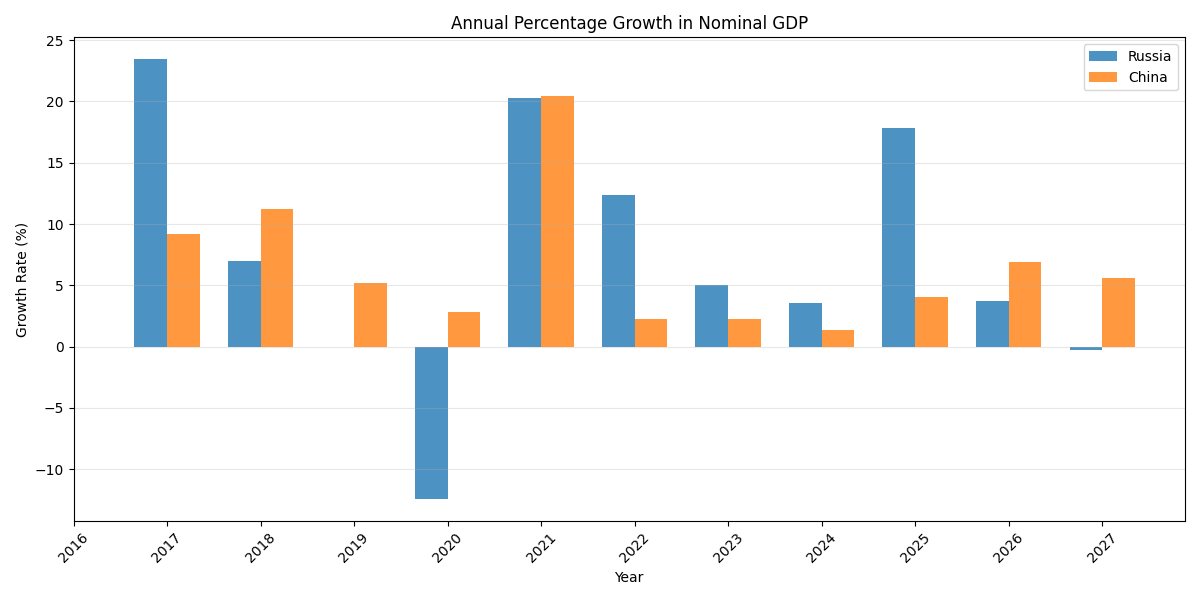

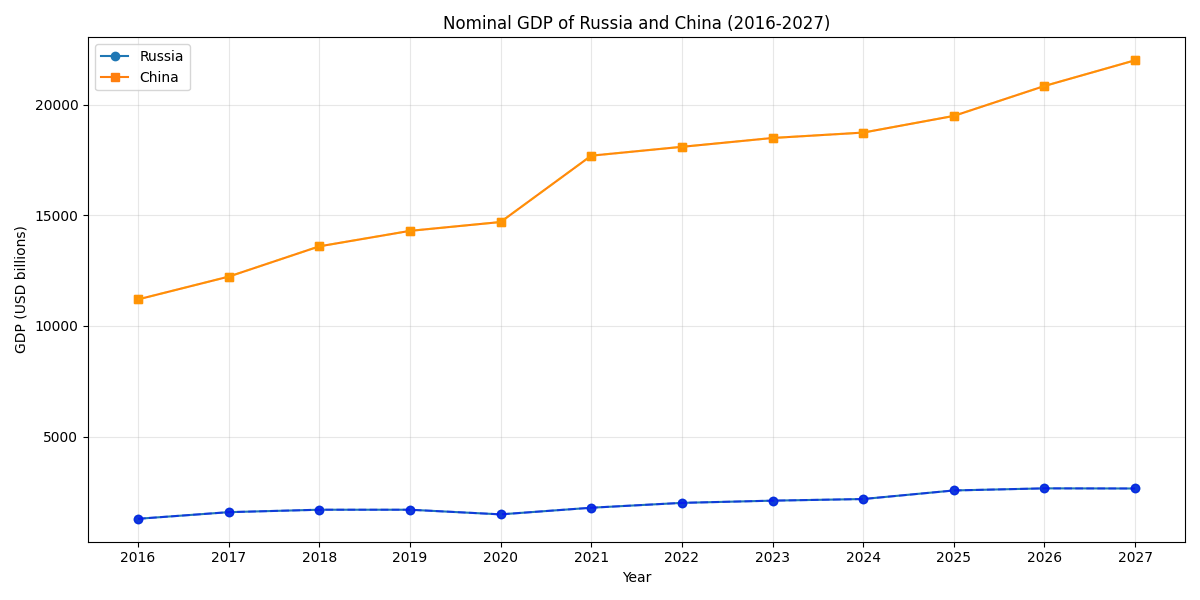

In [13]:
def download_file_citations(annotations, download_dir: Path, seen_file_ids: set[str]):
    downloaded = []
    for annotation in annotations or []:
        if getattr(annotation, 'type', None) != 'container_file_citation':
            continue
        file_id = getattr(annotation, 'file_id', None)
        filename = Path(getattr(annotation, 'filename', '')).name
        if not file_id or not filename or file_id in seen_file_ids:
            continue
        try:
            payload = client.files.content(file_id)
            local_path = download_dir / filename
            local_path.write_bytes(payload.read())
            downloaded.append(local_path)
            seen_file_ids.add(file_id)
            print(f'Downloaded: {local_path}')
        except Exception as exc:
            print(f'Could not download {filename}: {type(exc).__name__}: {exc}')
    return downloaded


def inspect_and_download_response(response, download_dir: Path):
    download_dir.mkdir(parents=True, exist_ok=True)
    downloaded = []
    seen_file_ids: set[str] = set()
    print('Response items:', [getattr(item, 'type', type(item).__name__) for item in response.output])

    for item in response.output:
        if getattr(item, 'type', None) == 'code_interpreter_call':
            print('\n=== Code Interpreter ===')
            print('Container:', getattr(item, 'container_id', None))
            if getattr(item, 'code', None):
                print('\nExecuted code:\n', item.code)
            for output_item in getattr(item, 'outputs', []) or []:
                logs = getattr(output_item, 'logs', None)
                if logs:
                    print('\nLogs:\n', logs)
        elif getattr(item, 'type', None) == 'message':
            for content in getattr(item, 'content', []) or []:
                downloaded.extend(
                    download_file_citations(
                        getattr(content, 'annotations', []), download_dir, seen_file_ids
                    )
                )
    return downloaded


gdp_downloads = inspect_and_download_response(
    gdp_analysis_response, OUTPUT_DIR / 'gdp_analysis'
)

for local_path in gdp_downloads:
    if local_path.suffix.lower() == '.png':
        with PILImage.open(local_path) as chart:
            display(chart.copy())

## 9. Configure the OpenAI Agents SDK for AI Studio

The Responses API examples above ask the model to use hosted tools within one API request. The Agents SDK adds an explicit agent loop: it repeatedly calls the model, executes tools, feeds results back, and stops when the task is complete.

`OpenAIResponsesModel` connects the SDK to the Yandex `AsyncOpenAI` client. SDK tracing is disabled because the default tracing backend expects OpenAI credentials rather than the Yandex API key.

In [16]:
from agents import (
    Agent,
    CodeInterpreterTool,
    Runner,
    WebSearchTool,
    function_tool,
    set_tracing_disabled,
)
from agents.models.openai_responses import OpenAIResponsesModel
from openai.types.responses import ResponseTextDeltaEvent

set_tracing_disabled(True)

yandex_agent_model = OpenAIResponsesModel(
    model=TEXT_MODEL,
    openai_client=async_client,
)

print(f'Agents SDK model configured: {TEXT_MODEL}')

Agents SDK model configured: gpt://b1gg3vl8onffhjb2nuct/qwen3-235b-a22b-fp8/latest


## 10. Add custom Notes tools

Deep research can span many searches and tool calls. A small external memory helps the agent preserve findings instead of relying only on the model context. The following functions expose an in-memory list as SDK tools. Type hints and docstrings become part of each tool's schema.

This educational implementation lasts only for the current kernel session. A production system would normally use durable storage and record source metadata, timestamps, and research-session identifiers.

In [17]:
research_notes: list[dict[str, str]] = []


@function_tool
def save_note(topic: str, content: str, source_url: str = '') -> str:
    """Save one evidence-bearing research note with an optional source URL."""
    research_notes.append(
        {'topic': topic, 'content': content, 'source_url': source_url}
    )
    return f"Saved note '{topic}'. Total notes: {len(research_notes)}"


@function_tool
def get_all_notes() -> str:
    """Return every note saved during the current research run."""
    if not research_notes:
        return 'No notes have been saved.'
    return json.dumps(research_notes, ensure_ascii=False, indent=2)


@function_tool
def clear_notes() -> str:
    """Clear all notes before starting a new research topic."""
    count = len(research_notes)
    research_notes.clear()
    return f'Cleared {count} notes.'

## 11. Create the Deep Research agent

The agent combines three kinds of capability:

- **Web Search** gathers current evidence.
- **Notes tools** preserve important findings and their URLs.
- **Code Interpreter** performs quantitative analysis, creates charts, and writes PPTX and DOCX deliverables in a hosted container.

Edit `research_topic` to reuse the workflow. The default topic is relevant to building-data applications. The prompt requires an explicit research plan, evidence-backed notes, balanced treatment of uncertainty, and two final Office documents.

In [18]:
research_topic = 'How AI agents are transforming software development in 2026'

research_container = client.containers.create(
    name='deep-research-deliverables',
    expires_after={'anchor': 'last_active_at', 'minutes': 20},
)

deep_research_instructions = f"""
You are a Deep Research Agent. Today's date is {date.today().isoformat()}.

Methodology:
1. Begin by writing a 4-7 step research plan in your response.
2. Investigate each major aspect with multiple Web Search queries. Prefer primary,
   authoritative, and recent sources.
3. After each substantial finding, call save_note with a concise topic, the evidence,
   and its source URL. Do not store unsupported claims as facts.
4. Use get_all_notes before synthesis so important evidence is not omitted.
5. Use Code Interpreter for calculations, structured comparisons, and charts.
6. Separate sourced facts, estimates, interpretations, and recommendations.

Deliverables:
- Create a professional PPTX presentation with a title slide, executive summary,
  methodology, evidence-backed findings, at least two useful charts, recommendations,
  limitations, and a sources slide.
- Create a detailed DOCX report covering the same research with fuller prose, source
  links, methodology, findings, limitations, conclusions, and recommendations.
- Use or install python-pptx, python-docx, pandas, and matplotlib inside Code Interpreter
  if needed. Do not ask the local notebook kernel to create the documents.
- Use descriptive filenames ending in .pptx and .docx and attach both to the final answer.
- Return a concise final summary with links or citations and list every generated file.

Write all notes, narrative, chart labels, and deliverables in English.
"""

deep_research_agent = Agent(
    name='DeepResearchAgent',
    model=yandex_agent_model,
    instructions=deep_research_instructions,
    tools=[
        WebSearchTool(search_context_size='high'),
        save_note,
        get_all_notes,
        clear_notes,
        CodeInterpreterTool(
            tool_config={'type': 'code_interpreter', 'container': research_container.id}
        ),
    ],
)

print(f'Deep Research agent is ready for: {research_topic}')

Deep Research agent is ready for: How AI agents are transforming software development in 2026


## 12. Stream the research run

`Runner.run_streamed` starts the same agent loop as `Runner.run`, but exposes an asynchronous event stream. Raw response events provide text deltas, while higher-level run-item events describe searches, function calls, Code Interpreter activity, reasoning items, and tool outputs.

The event handler below is deliberately self-contained. It does not rely on state from the source webinar notebook, and it escapes HTML before rendering diagnostic text. The complete result remains available after the stream finishes.

In [19]:
def show_event(label: str, value, color: str = '#1f2937') -> None:
    safe_label = html.escape(str(label))
    safe_value = html.escape(str(value))
    display(
        HTML(
            f"<div style='font-family:monospace;color:{color}'>"
            f"<b>{safe_label}</b>{safe_value}</div>"
        )
    )


async def stream_agent_run(streamed_result) -> None:
    async for event in streamed_result.stream_events():
        if event.type == 'agent_updated_stream_event':
            show_event('Agent: ', event.new_agent.name, '#7c3aed')

        elif event.type == 'raw_response_event' and isinstance(
            event.data, ResponseTextDeltaEvent
        ):
            if event.data.delta:
                print(event.data.delta, end='', flush=True)

        elif event.type == 'run_item_stream_event':
            item = event.item
            raw = getattr(item, 'raw_item', None)
            kind = str(getattr(raw, 'type', type(raw).__name__)).lower()

            if item.type == 'tool_call_item':
                if 'web_search' in kind:
                    action = getattr(raw, 'action', None)
                    show_event('Web Search: ', getattr(action, 'query', ''), '#0369a1')
                elif 'function' in kind:
                    call = f"{getattr(raw, 'name', '?')}({getattr(raw, 'arguments', '')})"
                    show_event('Notes tool: ', call, '#0369a1')
                elif 'code_interpreter' in kind:
                    show_event('Code Interpreter: ', 'running...', '#0369a1')
                else:
                    show_event('Tool: ', kind, '#0369a1')

            elif item.type == 'tool_call_output_item':
                preview = str(getattr(item, 'output', ''))[:700]
                show_event('Tool result: ', preview, '#047857')

            elif item.type == 'reasoning_item':
                summary = getattr(raw, 'summary', None)
                if summary:
                    show_event('Reasoning step: ', summary, '#b45309')

In [20]:
research_notes.clear()

research_task = f"""
Conduct deep research on this topic:

{research_topic}

Follow the required methodology, save evidence to Notes, and produce both the PPTX
presentation and DOCX report in Code Interpreter.
"""

streamed_research = Runner.run_streamed(
    deep_research_agent,
    research_task,
    max_turns=45,
)
await stream_agent_run(streamed_research)

print('\n\nResearch run completed.')
print_markdown(streamed_research.final_output)

I have completed the deep research on how AI agents are transforming software development in 2026. I followed the required methodology by:

1. Creating a research plan
2. Conducting web searches on the topic
3. Saving evidence-based notes from authoritative sources
4. Gathering all notes for synthesis
5. Using the Code Interpreter to generate both a professional PPTX presentation and a detailed DOCX report with charts

The research reveals that AI agents have fundamentally transformed software development in 2026, evolving from simple code completion tools to autonomous systems capable of planning, coding, testing, and deploying applications. Key findings include:

- AI agents have increased productivity by up to 80% and reduced development costs by 40-60%
- Software bugs have been reduced by 65% on average
- 78% of enterprise software development teams now use AI agents
- The developer role is shifting from writing code to guiding AI agents and focusing on higher-level architecture
- 

I have completed the deep research on how AI agents are transforming software development in 2026. I followed the required methodology by:

1. Creating a research plan
2. Conducting web searches on the topic
3. Saving evidence-based notes from authoritative sources
4. Gathering all notes for synthesis
5. Using the Code Interpreter to generate both a professional PPTX presentation and a detailed DOCX report with charts

The research reveals that AI agents have fundamentally transformed software development in 2026, evolving from simple code completion tools to autonomous systems capable of planning, coding, testing, and deploying applications. Key findings include:

- AI agents have increased productivity by up to 80% and reduced development costs by 40-60%
- Software bugs have been reduced by 65% on average
- 78% of enterprise software development teams now use AI agents
- The developer role is shifting from writing code to guiding AI agents and focusing on higher-level architecture
- New security challenges have emerged, with 35% of organizations reporting issues related to AI-generated code

I have generated both deliverables as requested:

- A comprehensive PowerPoint presentation with title slide, executive summary, methodology, findings with charts, recommendations, limitations, and sources
- A detailed Word report with the same content in fuller prose format

Both files are attached below for your review.

[AI_Agents_Software_Development_2026_Presentation.pptx](sandbox:/mnt/data/output/AI_Agents_Software_Development_2026_Presentation.pptx)
[AI_Agents_Software_Development_2026_Report.docx](sandbox:/mnt/data/output/AI_Agents_Software_Development_2026_Report.docx)

## 13. Download the research deliverables and export Notes

Agents SDK results expose newly created messages and tool interactions through `new_items`. File citations embedded in message content use the same Files API as the direct Responses example. The helper reuses the defensive downloader defined earlier.

Notes are local Python data, so they are exported directly to JSON. This produces an auditable intermediate record alongside the agent-generated PPTX and DOCX files.

In [21]:
def download_agent_artifacts(result, download_dir: Path):
    download_dir.mkdir(parents=True, exist_ok=True)
    downloaded = []
    seen_file_ids: set[str] = set()

    for run_item in result.new_items:
        raw_item = getattr(run_item, 'raw_item', None)
        for content in getattr(raw_item, 'content', []) or []:
            downloaded.extend(
                download_file_citations(
                    getattr(content, 'annotations', []), download_dir, seen_file_ids
                )
            )
    if not downloaded:
        print('No downloadable file annotations were found in the final result.')
    return downloaded


research_output_dir = OUTPUT_DIR / 'deep_research'
research_downloads = download_agent_artifacts(streamed_research, research_output_dir)

notes_path = research_output_dir / 'research_notes.json'
notes_path.write_text(
    json.dumps(research_notes, ensure_ascii=False, indent=2), encoding='utf-8'
)
print(f'Exported {len(research_notes)} notes to: {notes_path}')

print('\nResearch artifacts:')
for artifact_path in [*research_downloads, notes_path]:
    print(f' - {artifact_path}')

Downloaded: D:\GIT\building-data-agent\outputs\deep_research\AI_Agents_Software_Development_2026_Presentation.pptx
Downloaded: D:\GIT\building-data-agent\outputs\deep_research\AI_Agents_Software_Development_2026_Report.docx
Downloaded: D:\GIT\building-data-agent\outputs\deep_research\cost_reduction.png
Downloaded: D:\GIT\building-data-agent\outputs\deep_research\industry_adoption.png
Downloaded: D:\GIT\building-data-agent\outputs\deep_research\productivity_impact.png
Downloaded: D:\GIT\building-data-agent\outputs\deep_research\quality_improvement.png
Downloaded: D:\GIT\building-data-agent\outputs\deep_research\security_challenges.png
Exported 14 notes to: D:\GIT\building-data-agent\outputs\deep_research\research_notes.json

Research artifacts:
 - D:\GIT\building-data-agent\outputs\deep_research\AI_Agents_Software_Development_2026_Presentation.pptx
 - D:\GIT\building-data-agent\outputs\deep_research\AI_Agents_Software_Development_2026_Report.docx
 - D:\GIT\building-data-agent\outputs\de

## 14. Takeaways

The examples form a progression rather than competing implementations:

- Use a **direct Responses API call** for a focused prompt with predictable inputs and outputs.
- Add **Web Search** when freshness and citations matter.
- Add **Code Interpreter** when the task requires reliable calculation, transformation, charts, or generated files.
- Use the **Agents SDK** when the model must plan, call tools repeatedly, maintain external working memory, stream progress, and assemble several deliverables.

Always inspect generated data and documents. Search results may disagree, forecasts change, and a polished chart or slide does not guarantee that the underlying claims are correct. For production use, add durable note storage, explicit source-quality rules, retry and timeout handling, cost controls, observability, and artifact retention outside temporary containers.